# S20 - Evidencia de Aprendizaje 2

Proyecto Integrado III - Analítica de Datos (Andrés Felipe Palacio) - PREICA2601B020046

Por: Isabela Arango Verona

Mayo del 2026

# Entrega #1

## Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Perfilamiento de Datos

In [3]:
import kagglehub
import os

# Descargar el dataset
path = kagglehub.dataset_download("hamnamunir/social-media-user-behavior-dataset")

# Ver qué archivos hay en esa ruta
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Cargar el CSV
csv_path = os.path.join(path, archivos[1])
df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'social-media-user-behavior-dataset' dataset.
Archivos disponibles: ['README.md', 'social_media_user_behavior.csv', 'dataset-metadata.json']


,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


Perfilado de Datos

In [ ]:
!pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip

from ydata_profiling import ProfileReport

# Generar el perfil
profile = ProfileReport(df, title="Análisis de Comportamiento en Redes Sociales", explorative=True)

# Guardar como HTML para descargar
profile.to_file("exploracion_datos.html")

  Using cached https://github.com/pandas-profiling/pandas-profiling/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


/tmp/ipykernel_14972/4030527196.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 34/34 [00:00<00:00, 40.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Nota: La exploración de los datos se encuentra en el informe de la tarea.

# Entrega #2

### Descripción de Necesidades de Limpieza

In [5]:
# Check de Duplicados
print(f"Duplicados encontrados: {df.duplicated().sum()}")

# Check de Valores Nulos
print("\nValores Nulos por columna:")
print(df.isnull().sum().sum())

# Check de Tipos de Datos iniciales
print("\nTipos de datos actuales:")
print(df.dtypes.value_counts())

# Análisis de Variables Numéricas para Outliers
cols_numericas = ['age', 'daily_usage_hours', 'sessions_per_day', 'avg_session_duration_min']
df[cols_numericas].describe()

Duplicados encontrados: 0

Valores Nulos por columna:
0

Tipos de datos actuales:
object     19
int64      10
float64     5
Name: count, dtype: int64


,age,daily_usage_hours,sessions_per_day,avg_session_duration_min
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,26.986000,2.990650,5.024500,47.547400
std,7.649775,1.858501,2.249985,51.104393
min,13.000000,0.500000,1.000000,3.300000
25%,22.000000,1.600000,3.000000,18.975000
50%,27.000000,2.600000,5.000000,34.000000
75%,32.000000,3.900000,6.000000,56.000000
max,57.000000,12.000000,15.000000,594.000000


## Limpieza y Transformación de Datos

In [6]:
# 1. Convertir la fecha de registro a formato de fecha real
df['account_join_date'] = pd.to_datetime(df['account_join_date'])

# 2. Convertir columnas de texto a categorías para que Python las entienda mejor
# Creamos una lista de las columnas que son texto
columnas_a_categorizar = ['gender', 'country', 'profession', 'primary_platform',
                          'preferred_device', 'peak_usage_time', 'preferred_content_type',
                          'scroll_speed', 'primary_purpose', 'sleep_disruption',
                          'screen_time_concern', 'notification_frequency',
                          'privacy_setting', 'mood_while_scrolling']

for col in columnas_a_categorizar:
    df[col] = df[col].astype('category')

# 3. Verificamos el cambio
print("Nuevos tipos de datos:")
print(df.dtypes.value_counts())
print("\nEjemplo de la columna de fecha ya convertida:")
print(df['account_join_date'].head())

Nuevos tipos de datos:
int64             10
float64            5
object             4
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
datetime64[ns]     1
category           1
Name: count, dtype: int64

Ejemplo de la columna de fecha ya convertida:
0   2022-10-21
1   2024-12-03
2   2023-03-29
3   2024-04-26
4   2023-09-08
Name: account_join_date, dtype: datetime64[ns]


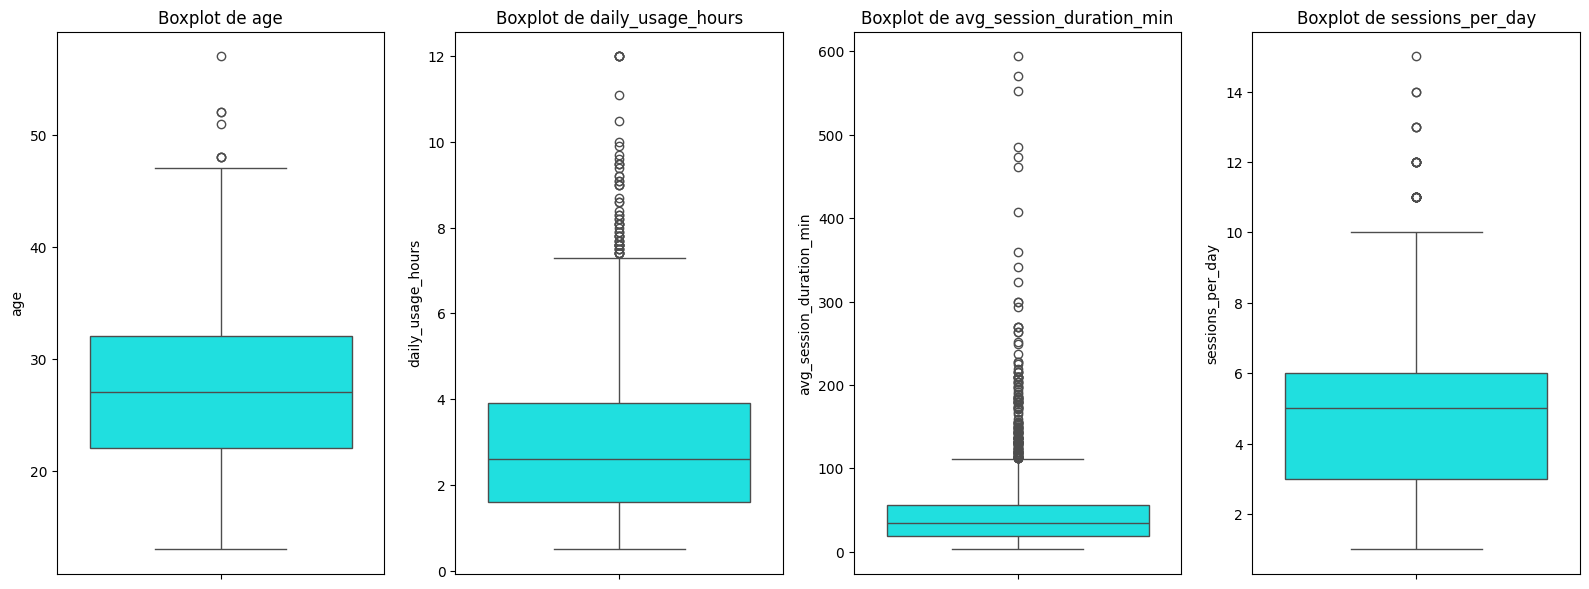


Resultados para 'avg_session_duration_min':
Límite superior (Bigote): 111.54 min
Cantidad de valores por encima del límite: 155


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas a analizar
vars_a_revisar = ['age', 'daily_usage_hours', 'avg_session_duration_min', 'sessions_per_day']

# Gráficos de caja (Boxplots)
plt.figure(figsize=(16, 6))

for i, var in enumerate(vars_a_revisar):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[var], color='cyan')
    plt.title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

# Calcular matemáticamente el límite de los outliers para la variable más extrema
Q1 = df['avg_session_duration_min'].quantile(0.25)
Q3 = df['avg_session_duration_min'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + (1.5 * IQR)

outliers_cantidad = len(df[df['avg_session_duration_min'] > limite_superior])
print(f"\nResultados para 'avg_session_duration_min':")
print(f"Límite superior (Bigote): {limite_superior:.2f} min")
print(f"Cantidad de valores por encima del límite: {outliers_cantidad}")

In [8]:
# 1. Tratamiento de Outliers (Capping / Winsorization)
# "Topar" los valores extremos al límite del bigote superior
df['avg_session_duration_min_clean'] = df['avg_session_duration_min'].clip(upper=111.54)

# 2. Correcciones de Valores (Uso de Replace y Map)
# Estandarizar la columna 'mood_while_scrolling'
# Agrupar estados de ánimo en categorías simples
mapeo_animo = {
    'Happy': 'Positivo',
    'Neutral': 'Neutral',
    'Anxious': 'Negativo',
    'Stressed': 'Negativo',
    'Bored': 'Neutral'
}

# Crear una nueva columna usando map
df['mood_category'] = df['mood_while_scrolling'].map(mapeo_animo)

# 3. Uso de Replace para corregir términos específicos
# Ejemplo: Cambiar 'Smartphone' por 'Celular' para localizar el lenguaje
df['preferred_device'] = df['preferred_device'].replace('Smartphone', 'Celular')

print("Estadísticas después del tratamiento de Outliers:")
print(df[['avg_session_duration_min', 'avg_session_duration_min_clean']].describe())
print("\nConteo de nuevas categorías de ánimo:")
print(df['mood_category'].value_counts())

Estadísticas después del tratamiento de Outliers:
       avg_session_duration_min  avg_session_duration_min_clean
count               2000.000000                     2000.000000
mean                  47.547400                       42.196750
std                   51.104393                       30.527184
min                    3.300000                        3.300000
25%                   18.975000                       18.975000
50%                   34.000000                       34.000000
75%                   56.000000                       56.000000
max                  594.000000                      111.540000

Conteo de nuevas categorías de ánimo:
mood_category
Neutral     670
Positivo    351
Negativo    306
Name: count, dtype: int64


/tmp/ipykernel_5370/166995053.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['preferred_device'] = df['preferred_device'].replace('Smartphone', 'Celular')


In [9]:
# 1. Cambiar la granularidad: Resumen promedio por Plataforma y Categoría de Ánimo
# Esto dirá en qué plataforma la gente se siente más "Negativa" o "Positiva"
df_agrupado = df.groupby(['primary_platform', 'mood_category'], observed=True).agg({
    'daily_usage_hours': 'mean',
    'self_reported_mental_health_score': 'mean',
    'user_id': 'count'
}).reset_index()

# Renombrar columnas para que sean claras
df_agrupado.columns = ['Plataforma', 'Sentimiento', 'Uso_Promedio_Hrs', 'Salud_Mental_Promedio', 'Total_Usuarios']

# 2. Guardar el dataset limpio final para tu entrega
df.to_csv('Arango_Isabela_EA2_Limpio.csv', index=False)

print("Agregación completada con éxito")
df_agrupado.head(10)

Agregación completada con éxito


,Plataforma,Sentimiento,Uso_Promedio_Hrs,Salud_Mental_Promedio,Total_Usuarios
0,Facebook,Negativo,3.184783,6.393478,46
1,Facebook,Neutral,2.648276,6.273563,87
2,Facebook,Positivo,3.258333,6.166667,48
3,Instagram,Negativo,2.703333,6.026667,60
4,Instagram,Neutral,3.553333,6.169630,135
5,Instagram,Positivo,2.609836,6.139344,61
6,LinkedIn,Negativo,3.726667,5.973333,15
7,LinkedIn,Neutral,3.060526,6.213158,38
8,LinkedIn,Positivo,3.068182,5.822727,22
9,Pinterest,Negativo,3.361538,6.661538,13
